In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)

sns.set_theme(style='whitegrid')
print("✅ Imports OK")

✅ Imports OK


In [2]:
DATA = joblib.load("../../04_machine_learning/models/data_splits.pkl")
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, FEATURES = DATA

print(f"✅ Données chargées")
print(f"   Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}")

✅ Données chargées
   Train : 387,554 | Test : 96,889


In [3]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1),

    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=42, eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    print(f"🔄 Entraînement : {name}...")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred  = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc  = average_precision_score(y_test, y_proba)
    f1      = f1_score(y_test, y_pred)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'ROC-AUC': roc_auc, 'PR-AUC': pr_auc, 'F1': f1
    }
    print(f"   ✅ ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1: {f1:.4f}\n")

print("✅ 3 modèles entraînés !")

🔄 Entraînement : Logistic Regression...
   ✅ ROC-AUC: 0.6940 | PR-AUC: 0.6385 | F1: 0.5371

🔄 Entraînement : Random Forest...
   ✅ ROC-AUC: 0.9402 | PR-AUC: 0.9479 | F1: 0.8614

🔄 Entraînement : XGBoost...
   ✅ ROC-AUC: 0.9496 | PR-AUC: 0.9562 | F1: 0.8805

✅ 3 modèles entraînés !


In [4]:
comparison = []
for name, res in results.items():
    report = classification_report(y_test, res['y_pred'], output_dict=True)
    comparison.append({
        'Modèle'    : name,
        'Accuracy'  : round(report['accuracy'], 4),
        'Precision' : round(report['1']['precision'], 4),
        'Recall'    : round(report['1']['recall'], 4),
        'F1-Score'  : round(res['F1'], 4),
        'ROC-AUC'   : round(res['ROC-AUC'], 4),
        'PR-AUC'    : round(res['PR-AUC'], 4),
    })

df_comp = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False)
print("=== TABLEAU COMPARATIF ===")
display(df_comp)

=== TABLEAU COMPARATIF ===


,Modèle,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
2,XGBoost,0.8963,0.9319,0.8346,0.8805,0.9496,0.9562
1,Random Forest,0.8822,0.9341,0.7993,0.8614,0.9402,0.9479
0,Logistic Regression,0.6209,0.6096,0.4800,0.5371,0.6940,0.6385


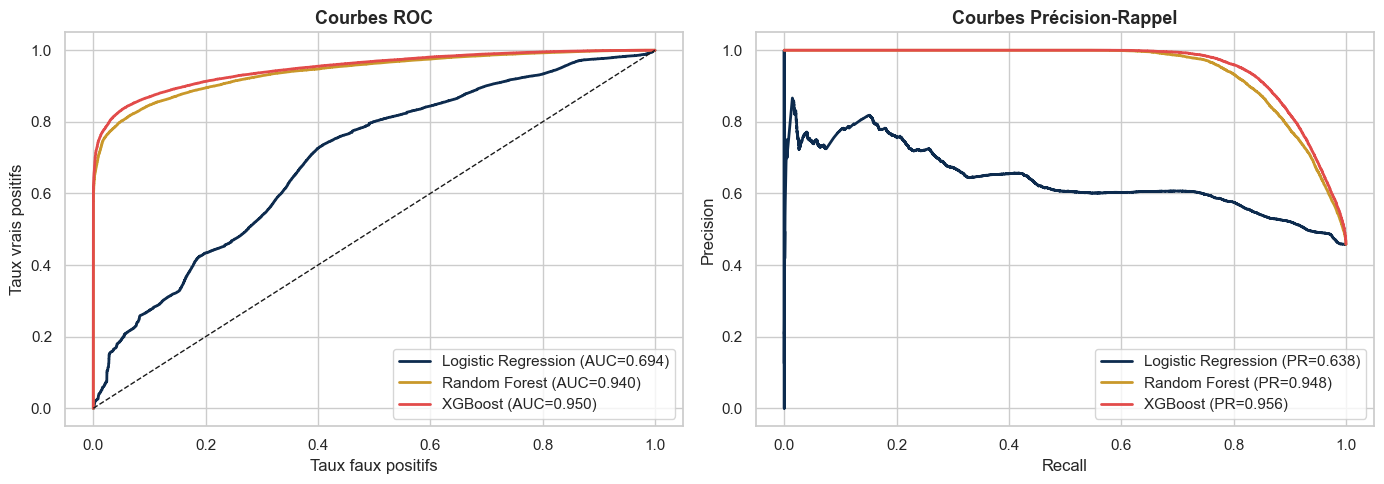

✅ Courbes sauvegardées


In [5]:
colors = ['#0D2B4E', '#C9982A', '#E24B4A']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.3f})",
                 color=color, lw=2)

axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_title('Courbes ROC', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Taux faux positifs')
axes[0].set_ylabel('Taux vrais positifs')
axes[0].legend()

for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec, prec, label=f"{name} (PR={res['PR-AUC']:.3f})",
                 color=color, lw=2)

axes[1].set_title('Courbes Précision-Rappel', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig("../../04_machine_learning/models/roc_pr_curves.png", dpi=150)
plt.show()
print("✅ Courbes sauvegardées")

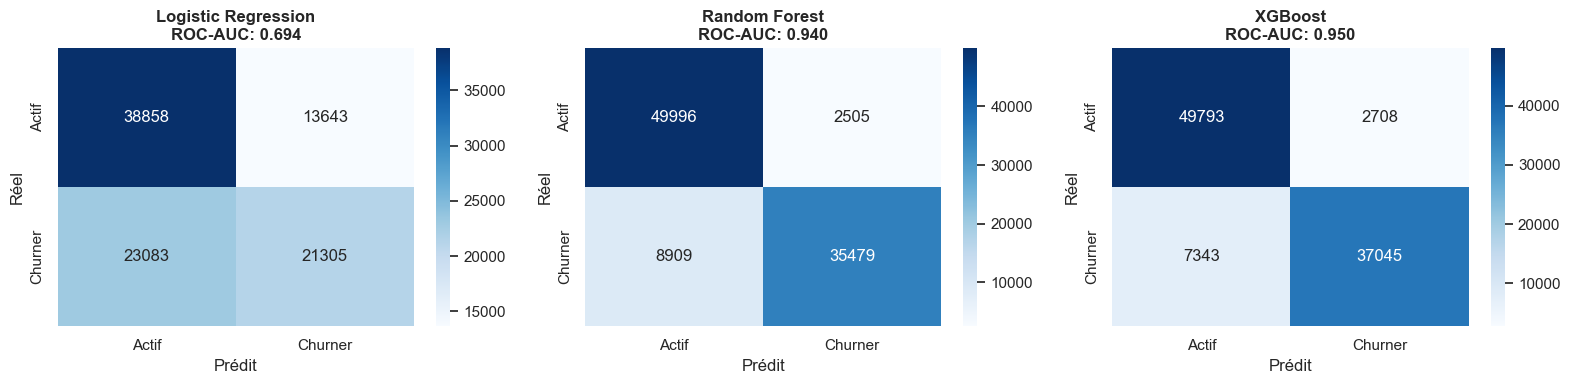

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Actif','Churner'],
                yticklabels=['Actif','Churner'])
    ax.set_title(f'{name}\nROC-AUC: {res["ROC-AUC"]:.3f}', fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.savefig("../../04_machine_learning/models/confusion_matrices.png", dpi=150)
plt.show()

In [7]:
best_name  = max(results, key=lambda x: results[x]['ROC-AUC'])
best_model = results[best_name]['model']

print(f"🏆 Meilleur modèle : {best_name}")
print(f"   ROC-AUC : {results[best_name]['ROC-AUC']:.4f}")
print(f"   F1-Score: {results[best_name]['F1']:.4f}")

joblib.dump(best_model, "../../04_machine_learning/models/model_final.pkl")
joblib.dump(results,    "../../04_machine_learning/models/all_results.pkl")
joblib.dump(df_comp,    "../../04_machine_learning/models/comparison_df.pkl")
print("✅ Modèle final sauvegardé !")

🏆 Meilleur modèle : XGBoost
   ROC-AUC : 0.9496
   F1-Score: 0.8805
✅ Modèle final sauvegardé !
